### note
<br/>

### note name

In [1]:
# pip install ipynbname

import ipynbname
nb_name = ipynbname.name()
nb_path = ipynbname.path()

nb_name

'2Samples Classical_GRU_P197 SEEDs_ini_2'

## Hyper parameters

In [2]:
SEED = 2
# SEEDs = range(10) # 0~9
L_RATE = 0.2 # 0.2
N_STEPS = 1000000
NUM_SEEDs = 50

In [3]:
from jax.config import config
config.update("jax_enable_x64", True)

import jax
import jax.numpy as jnp
import pennylane as qml
from jax.example_libraries import optimizers
from jax.example_libraries import stax
from jax import value_and_grad
from jax import lax

import optax
# from functools import partial
import time
import matplotlib.pyplot as plt
import pickle


from SQGRU_j7x import SQGRU, qgru
from Classical_RNN import simple_rnn, gru, count_parameters

### force to use cpu

In [4]:
jax.config.update('jax_platform_name', 'cpu')

In [5]:
qml.version()

'0.31.1'

## Oscillations

In [6]:
def damped_shm(fre, damp):
    amp = 0.7
    num_data = 151
    x = jnp.array(range(num_data))
    y = jnp.sin(x*fre)*jnp.exp(x*damp)*amp

    return y

In [7]:
osc1 = damped_shm(0.4, 0)
osc2 = damped_shm(0.6, -0.02)

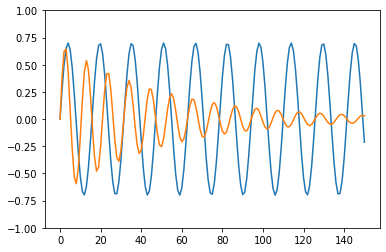

In [8]:
plt.plot(osc1)
plt.plot(osc2)
plt.ylim(-1,1)
plt.show()

In [9]:
oscillations = jnp.array([osc1,osc2])
true_data = jnp.expand_dims(oscillations, 2)
train_input = true_data[:,0:100,:]
train_target = true_data[:,1:101,:]

## Model
### Hyper parameters

In [10]:
# model parameters
OUT_DIM = 7

In [11]:
init_fun, qgru_rnn = stax.serial(gru(OUT_DIM, sequence_out=True), stax.Dense(1))

In [12]:
key = jax.random.PRNGKey(SEED)
key1, key2 = jax.random.split(key, num=2)
_, params = init_fun(key1, jnp.shape(train_input))

In [13]:
count_parameters(params)

197

## Train

In [14]:
step_size = L_RATE
optimizer = optax.adam(step_size)
opt_state = optimizer.init(params)

In [15]:

@jax.jit
def loss_fn(params, xs, ys):
#     prediction = qgru_rnn(params, xs)[:,:,0:1]
    prediction = qgru_rnn(params, xs)
#     prediction = cls_predict(xs, 10, params)
    
    return jnp.mean((prediction - ys)**2) # the prediction shape


# def update(i_step, params, xs, ys, opt_state):
#     loss, grads = value_and_grad(loss_fn)(params, xs, ys)
#     updates, opt_state = optimizer.update(grads, opt_state)
#     params = optax.apply_updates(params, updates)
#     return params, opt_state, loss


In [16]:
minLoss = 1000
best_params = params
lossList = []
loc_params_list = []
reset_steps = []

In [17]:
def ck_lr(old_lr, new_lr):
    d_lr = old_lr - new_lr
    return d_lr >= 0 and d_lr/new_lr < 1e-2

### prediction

In [18]:
_, qgru_rnn2 = stax.serial(gru(OUT_DIM, sequence_out=True), stax.Dense(1))

In [19]:
@jax.jit
def jit_rnn(params, inputs):
    return qgru_rnn2(params, inputs)

In [20]:
true1 = true_data.squeeze()[:,0:100]
true2 = true_data.squeeze()[:,100:]
xs = train_input

In [21]:
# for classical rnn to predict the trend
def cls_predict(inp, pred_length, params):
    ys = jit_rnn(params, inp)
    new_inp = inp
    for _ in range(pred_length-1):
        new_inp = jnp.concatenate([new_inp, ys[:,-1:]], axis=1)
        ys = jit_rnn(params, new_inp)
    return ys

### start

In [22]:
update_lr = True
lr_factor = 1
locLossList = [1000,1000,1000]
locLoss = 1000
loc_params = params



start = time.time()
for i in range(N_STEPS):
    
    if update_lr != 0:
        if update_lr < 0:
            params = loc_params
        else:
            locLossList = [1000,1000,1000]
            locLoss = 1000
            loc_params_list.append(loc_params)
            reset_steps.append(i)
            # reset parameters
            key1, key2 = jax.random.split(key2, num=2)
            _, params = init_fun(key1, jnp.shape(train_input))
            loc_params = params
            # stop when collect X local best parameters
            if len(loc_params_list) > NUM_SEEDs:
                break
        update_lr = 0
            
        # update learning rate
        optimizer = optax.adam(step_size)
        opt_state = optimizer.init(params)
        
        print('learning rate:', step_size)

        def update(i_step, params, xs, ys, opt_state):
            loss, grads = value_and_grad(loss_fn)(params, xs, ys)
            updates, opt_state = optimizer.update(grads, opt_state)
            params = optax.apply_updates(params, updates)
            return params, opt_state, loss
    
    pre_params = params
    params, opt_state, loss = update(i, params, train_input, train_target, opt_state)
    print('{}: {}   {} sec      '.format(i, loss, time.time()-start), end='\r')
    if loss < minLoss:
        best_params = pre_params
        minLoss = loss
    if loss < locLoss:
        loc_params = pre_params
        locLoss = loss
    if (i+1) % 100 == 0:
        # update learning rate?
        if loss > locLossList[0] and locLossList[1] > locLossList[0] and locLossList[2] > locLossList[0]:
            step_size /= 2
            update_lr = -1
        elif ck_lr(locLossList[2], loss) and ck_lr(locLossList[1], locLossList[2]) and ck_lr(locLossList[0], locLossList[1]):
            # reset
            step_size = L_RATE
            update_lr = 1
        locLossList[0] = locLossList[1]
        locLossList[1] = locLossList[2]
        locLossList[2] = loss
        
        
        lossList.append(loss)
        print('{}: {}   {} sec      '.format(i, loss, time.time()-start))

learning rate: 0.2
99: 0.0005651003630732695   1.7147290706634521 sec      
199: 0.0001704589558760819   2.4505727291107178 sec       
299: 9.325658346118598e-05   3.1774096488952637 sec       
399: 6.754590583081341e-05   3.8937134742736816 sec      
499: 0.00021806052801256657   4.577770471572876 sec       
599: 4.567190550998401e-05   5.260115385055542 sec        
699: 0.000578690640201821   5.998928070068359 sec         
799: 4.192723500807257e-05   6.690142631530762 sec        
899: 3.7337981780483915e-05   7.422231674194336 sec       
999: 3.612197493563152e-05   8.109673023223877 sec        
1099: 3.535117940062813e-05   8.819066047668457 sec       
1199: 3.4794860013014965e-05   9.482758045196533 sec      
1299: 8.99551623097102e-05   10.202207565307617 sec        
1399: 4.688275155007004e-05   10.897155523300171 sec       
1499: 3.9992892273678195e-05   11.550244808197021 sec      
learning rate: 0.1
1599: 0.019414704938668495   12.214104890823364 sec       
1699: 0.0183970364

26399: 3.4567701456825726e-05   177.7007884979248 sec       
26499: 3.4294069232154054e-05   178.35615921020508 sec      
26599: 3.406507025106988e-05   179.01898789405823 sec       
learning rate: 0.2
26699: 0.0006285733925569043   179.73467421531677 sec      
26799: 0.0002451386062533514   180.38696265220642 sec       
26899: 0.00016173046499202138   181.04019832611084 sec      
26999: 0.00013280995687562134   181.70575714111328 sec      
27099: 9.534423714595915e-05   182.3498375415802 sec        
27199: 7.917255319865243e-05   183.0274248123169 sec       
27299: 6.751525771933645e-05   183.67514824867249 sec      
27399: 5.793009426966483e-05   184.33281469345093 sec       
27499: 9.418704975392049e-05   184.98346257209778 sec       
27599: 5.3385391086894157e-05   185.62928366661072 sec      
27699: 4.726701911578534e-05   186.29727125167847 sec       
27799: 4.2995117969243204e-05   186.94642090797424 sec      
27899: 4.019526617173758e-05   187.60890197753906 sec       
27999: 3

52899: 0.00206729725603817   359.55466771125793 sec        
52999: 0.002017763773432021   360.2929117679596 sec        
53099: 0.0019716457483783807   361.0021550655365 sec       
53199: 0.001925643314574174   361.7540993690491 sec        
53299: 0.0037044303379889865   362.44853353500366 sec      
53399: 0.0018352333496718333   363.15282106399536 sec      
53499: 0.0017899354266184032   363.8921580314636 sec       
53599: 0.0017451184775860884   364.5788879394531 sec       
53699: 0.0017008273555842567   365.32648277282715 sec      
53799: 0.0017896161429432084   366.0655941963196 sec       
53899: 0.0016152698144153094   366.83563137054443 sec      
53999: 0.0015733188217428534   367.483601808548 sec        
54099: 0.0015323930641991008   368.18542766571045 sec      
54199: 0.0014925690611063925   368.92754793167114 sec      
54299: 0.0014596072409650627   369.6081078052521 sec       
54399: 0.0014170052807010256   370.3914225101471 sec       
54499: 0.001380689956508478   371.087130

79299: 4.479802375007808e-05   574.2571892738342 sec       
79399: 4.282076514999191e-05   575.1324470043182 sec       
79499: 4.122523274707969e-05   576.0595417022705 sec       
79599: 0.002446580619288534   577.031998872757 sec         
79699: 4.305150667566894e-05   578.0115044116974 sec       
79799: 3.9948731600949294e-05   578.9723119735718 sec      
79899: 3.8237339964808556e-05   579.8780515193939 sec      
79999: 0.0014114100765052883   580.8023149967194 sec       
80099: 3.9202873193278265e-05   581.679666519165 sec       
80199: 3.7070305319795124e-05   582.5348961353302 sec      
80299: 3.607323171791486e-05   583.3975117206573 sec       
80399: 4.014109204158986e-05   584.3193161487579 sec       
80499: 3.6514323096748225e-05   585.1570258140564 sec      
80599: 3.563051669893037e-05   586.0241711139679 sec       
80699: 4.29489778056771e-05   586.9070625305176 sec        
80799: 3.585952025413747e-05   587.8089179992676 sec       
80899: 3.511436853107632e-05   588.71729

105799: 8.711764229674917e-05   815.3834164142609 sec       
105899: 6.979285136383795e-05   816.3296899795532 sec      
105999: 6.145096227175492e-05   817.2195620536804 sec      
106099: 5.612168830024956e-05   818.1980931758881 sec       
106199: 5.207987303543278e-05   819.4087100028992 sec       
106299: 4.884345585521217e-05   820.6524310112 sec          
106399: 4.623318864652222e-05   821.5611627101898 sec       
106499: 4.414168134283963e-05   822.421186208725 sec        
106599: 4.246465664130812e-05   823.3546829223633 sec       
106699: 4.1100508844946006e-05   824.2783317565918 sec      
106799: 0.00043147063080232524   825.2154276371002 sec      
106899: 4.468002252707225e-05   826.0868952274323 sec       
106999: 4.0434538152254895e-05   827.0350470542908 sec      
107099: 3.8826849577211896e-05   827.904937505722 sec       
107199: 3.788082205738376e-05   828.825044631958 sec        
107299: 3.718885292695875e-05   829.7681035995483 sec       
107399: 3.6634396373402486

...

157399: 0.0006979936539442895   1311.425104856491 sec       
157499: 0.00027254307866673646   1312.336808681488 sec       
157599: 0.0001331262628145175   1313.2605020999908 sec       
learning rate: 0.05
157699: 0.00010472607756553407   1314.1390149593353 sec      
157799: 7.649696550950425e-05   1315.0349762439728 sec       
157899: 6.83890459692398e-05   1315.9100723266602 sec       
157999: 6.323784649233264e-05   1316.8324327468872 sec      
158099: 5.8864589797163946e-05   1317.7349526882172 sec      
158199: 5.4976286407055614e-05   1318.5897827148438 sec      
158299: 5.151513209928132e-05   1319.4030058383942 sec       
158399: 4.841416686695843e-05   1320.385633945465 sec        
158499: 4.558363416176152e-05   1321.2865641117096 sec       
158599: 4.294856364397517e-05   1322.2164874076843 sec       
158699: 4.0519673140876924e-05   1323.166823387146 sec       
158799: 3.8399503156825676e-05   1324.0641829967499 sec      
158899: 3.6646673454286384e-05   1325.0206007957458 s

170399: 3.434333535972784e-05   1435.7834296226501 sec       
170499: 3.4242517894672685e-05   1436.8482646942139 sec      
170599: 3.4217944023361545e-05   1437.926012992859 sec       
learning rate: 0.2
170699: 0.00031990491402318465   1439.0014238357544 sec      
170799: 0.0001932942760358506   1439.9288852214813 sec       
170899: 0.00014262091327836817   1440.8840117454529 sec      
170999: 0.00011018318746305331   1441.8650012016296 sec      
171099: 8.98449488608396e-05   1442.8103606700897 sec        
171199: 0.0001774094051532118   1443.7107210159302 sec       
171299: 9.058675629022527e-05   1444.6129474639893 sec       
171399: 6.791494636073269e-05   1445.5167164802551 sec      
171499: 5.657325544550321e-05   1446.4355807304382 sec       
171599: 4.8973007259086094e-05   1447.3764481544495 sec      
171699: 4.327124974799607e-05   1448.3789739608765 sec       
171799: 3.936161179708261e-05   1449.2533740997314 sec       
171899: 3.691450707767802e-05   1450.2003400325775 s

196599: 5.2086404386655986e-05   1681.3343496322632 sec      
learning rate: 0.1
196699: 0.000575330509364655   1682.2595233917236 sec       
196799: 0.0003585813186882604   1683.1834127902985 sec       
196899: 0.00018429077780657903   1684.1007993221283 sec      
learning rate: 0.05
196999: 8.785657113239043e-05   1685.007043838501 sec        
197099: 8.065635933840445e-05   1685.9649271965027 sec       
197199: 5.757225087534765e-05   1686.9057824611664 sec       
197299: 5.136886601901303e-05   1687.8147087097168 sec       
197399: 4.634583728808326e-05   1688.7316498756409 sec       
197499: 4.255426101738071e-05   1689.6119139194489 sec       
197599: 0.00046969116652257074   1690.5137269496918 sec      
197699: 0.00020608695037912942   1691.4408838748932 sec      
197799: 0.00014371773186915227   1692.3319087028503 sec      
learning rate: 0.025
197899: 7.929726137140692e-05   1693.2135698795319 sec       
197999: 5.1632265319304426e-05   1694.1387457847595 sec      
198099: 4.8

222399: 3.932143950987916e-05   1924.3680045604706 sec       
222499: 8.284142996121962e-05   1925.2873740196228 sec       
222599: 4.2232542824078226e-05   1926.238430261612 sec       
222699: 3.87945568879564e-05   1927.208821296692 sec         
222799: 3.6875701761064815e-05   1928.182936668396 sec       
222899: 3.571519109514402e-05   1929.1076865196228 sec       
222999: 3.5002972518607035e-05   1930.044474363327 sec       
223099: 3.4570122247186586e-05   1930.9798891544342 sec      
223199: 3.429085898168157e-05   1931.9266414642334 sec       
223299: 3.4093444514446695e-05   1932.867748260498 sec       
223399: 0.00015743112488113213   1933.8070514202118 sec      
223499: 9.828761019657105e-05   1934.7110414505005 sec       
223599: 7.704842667312775e-05   1935.6503365039825 sec      
learning rate: 0.025
223699: 0.0001240278930526827   1936.502282857895 sec        
223799: 5.801858325091104e-05   1937.4936702251434 sec       
223899: 4.870173193037613e-05   1938.4940803050995

248099: 0.00012166521073229305   2174.147133588791 sec       
248199: 0.00010449204745583092   2175.2474591732025 sec      
248299: 8.940051823332853e-05   2176.4234611988068 sec       
248399: 8.341281745239292e-05   2177.548847436905 sec        
248499: 6.789111172895338e-05   2178.7607033252716 sec      
248599: 5.8341491245165087e-05   2179.87038230896 sec        
248699: 5.117046580691368e-05   2181.0169475078583 sec       
248799: 4.5918656955870634e-05   2182.164484024048 sec       
248899: 4.247737902478294e-05   2183.285798549652 sec        
248999: 4.0315307603808286e-05   2184.3477091789246 sec      
249099: 3.8878937978969726e-05   2185.432165622711 sec       
249199: 0.0003254924556666018   2186.569363117218 sec        
249299: 7.154389373832384e-05   2187.643365383148 sec        
249399: 4.9255590816229804e-05   2188.844363927841 sec       
learning rate: 0.1
249499: 0.004273964904151248   2189.984790325165 sec       
249599: 0.0024267885833090426   2191.0867326259613 sec

In [23]:
minLoss

Array(3.30878043e-05, dtype=float64)

In [24]:
# Save
# Loss, minLoss, params, best_params, loc_params_list, reset_steps
with open(nb_name+'_state.pkl', 'wb') as f:
    pickle.dump((lossList, minLoss, params, best_params, loc_params_list, reset_steps), f)

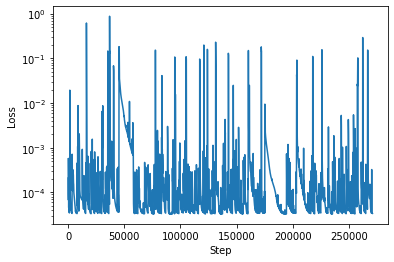

In [25]:
plt.plot([x*100 for x in range(len(lossList))], lossList)
plt.ylabel('Loss')
plt.xlabel('Step')
plt.yscale("log")
plt.show()

## Result

### best parameters

In [26]:
ys = cls_predict(xs, 50, best_params)

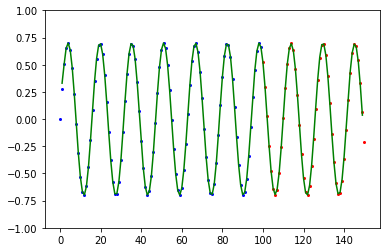

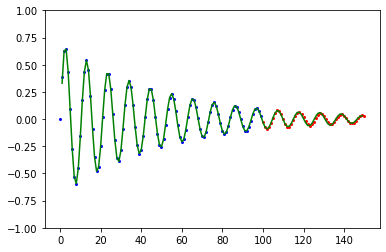

In [27]:
for idx in [0, 1]:
    plt.scatter(range(len(true1[idx])), true1[idx], c='b', s=4)
    plt.scatter(jnp.array(range(len(true2[idx])))+len(true1[idx]), true2[idx], c='r', s=4)
    plt.plot(jnp.array(range(len(ys[idx])))+1, ys[idx], c='g')
    plt.ylim(-1,1)
    plt.show()

### final parameters

In [28]:
ys = cls_predict(xs, 50, params)

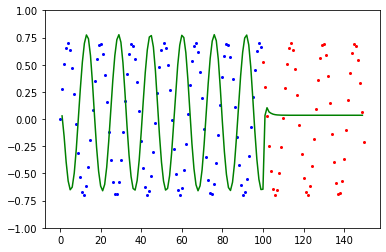

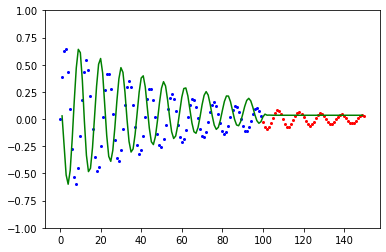

In [29]:
for idx in [0, 1]:
    plt.scatter(range(len(true1[idx])), true1[idx], c='b', s=4)
    plt.scatter(jnp.array(range(len(true2[idx])))+len(true1[idx]), true2[idx], c='r', s=4)
    plt.plot(jnp.array(range(len(ys[idx])))+1, ys[idx], c='g')
    plt.ylim(-1,1)
    plt.show()

## Load & find the best parameters

In [22]:
# load
# Loss, minLoss, params, best_params, loc_params_list, reset_steps
with open(nb_name+'_state.pkl', 'rb') as f:
    lossList, minLoss, params, best_params, loc_params_list, reset_steps = pickle.load(f)

In [23]:
test_result = []
min_loss = 1000
k = 0
for i in reset_steps[1:]:
    k += 1
    j = int(i/100 -1)
    i_loss = lossList[j]
    i_params = loc_params_list[k]
    
    ys = cls_predict(xs, 50, i_params)
    
    t_loss = jnp.mean((true2[:,:-1]-ys[:,-50:,0])**2)
    test_result.append([i,i_loss,t_loss,i_params,ys])
    if t_loss < min_loss:
        min_loss = t_loss
        min_idx = k-1
        min_ys = ys
        
test_result[min_idx]

[235400,
 Array(3.31311445e-05, dtype=float64),
 Array(1.05497975e-05, dtype=float64),
 [((Array([[ 0.03536288,  1.76132135, -0.75378132,  2.49081261,  1.16567757,
             1.37916779, -1.56610796]], dtype=float64),
    Array([[ 0.17687598, -0.86198484,  1.45379579,  1.96805584,  0.92449425,
             2.34371334,  0.55222117],
           [ 1.07512782, -0.01362182, -1.71556715, -0.70442619, -0.359803  ,
             0.63295377,  0.30585457],
           [ 0.08098478,  0.14876207,  0.45397506,  0.0153446 , -0.25824342,
            -0.7888438 , -0.39862381],
           [ 1.12156658, -0.055923  , -3.22488777, -1.46562547,  2.30872287,
             3.04799922, -0.34774405],
           [-2.11999291, -3.13583886, -0.36093886, -1.10953495,  1.0234838 ,
            -1.93822186,  0.51329359],
           [-1.51771149,  0.07505429,  0.29787485, -0.9802897 , -1.87988534,
             2.59103058, -1.78079299],
           [-0.28006261, -1.59785155,  4.36046172,  1.44925337, -1.08211689,
       

In [24]:
# Save results
# [[i,i_loss,t_loss,i_params,ys]...]
with open(nb_name+'_test_result.pkl', 'wb') as f:
    pickle.dump(test_result, f)

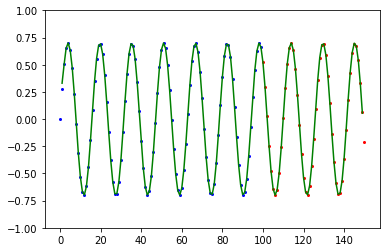

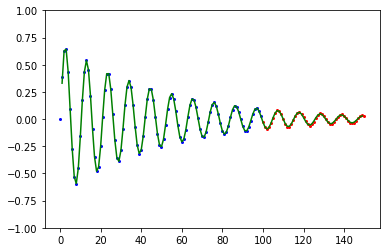

In [32]:
for idx in [0, 1]:
    plt.scatter(range(len(true1[idx])), true1[idx], c='b', s=4)
    plt.scatter(jnp.array(range(len(true2[idx])))+len(true1[idx]), true2[idx], c='r', s=4)
    plt.plot(jnp.array(range(len(min_ys[idx])))+1, min_ys[idx], c='g')
    plt.ylim(-1,1)
    plt.show()

best: [235400, Array(3.31311445e-05, dtype=float64), Array(1.05497975e-05, dtype=float64)]
3600 3.3899743204891755e-05 0.002410618956204541


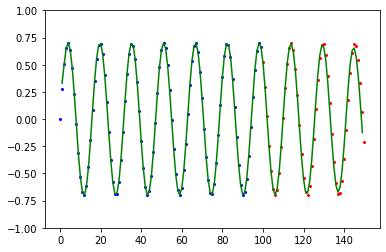

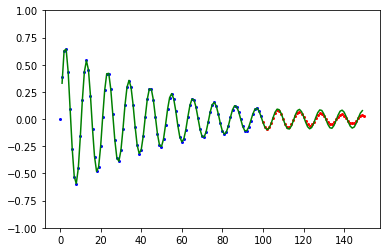

8000 3.362093349092986e-05 0.038597379539557934


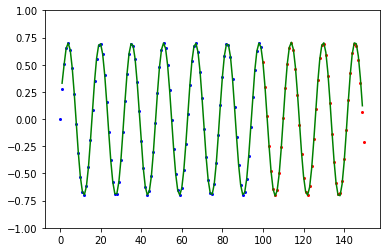

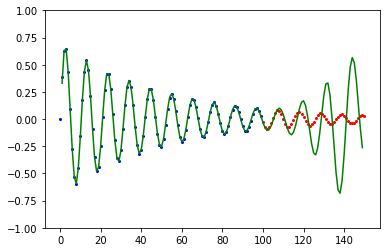

12600 6.735147648979582e-05 0.00029212243195153386


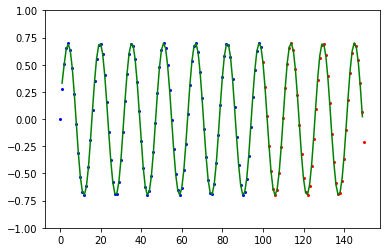

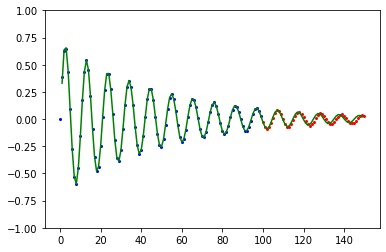

15700 3.389790283182339e-05 0.0004186548807791715


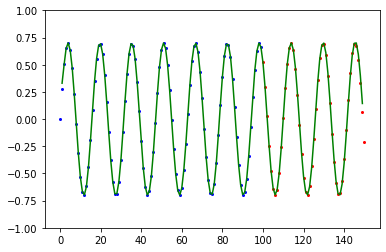

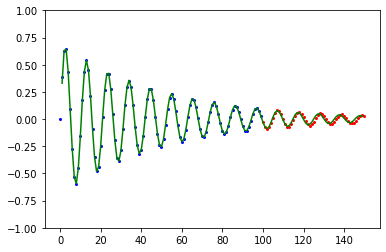

20500 3.3438062021157145e-05 0.01842341966129524


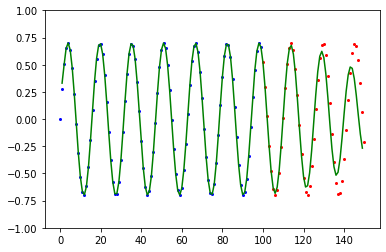

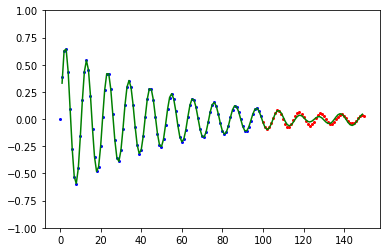

23600 3.391212644645582e-05 0.008508668043197358


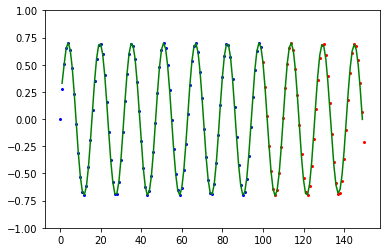

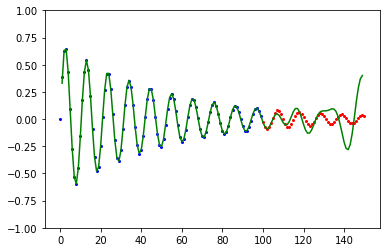

26600 3.406507025106988e-05 0.00045956777856521856


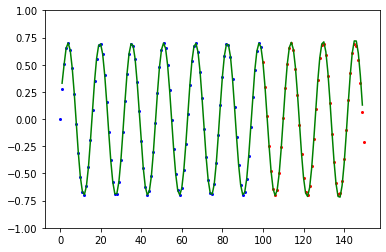

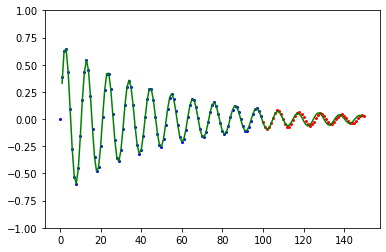

30000 3.377201739576636e-05 0.00027504985229910263


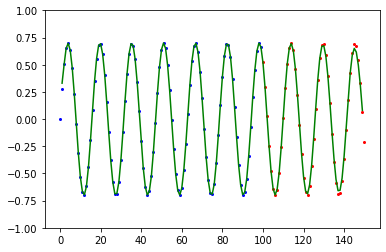

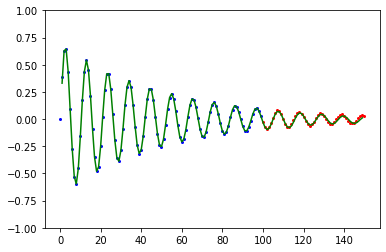

33200 3.408583613459425e-05 0.03302880359401142


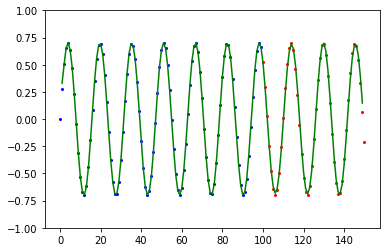

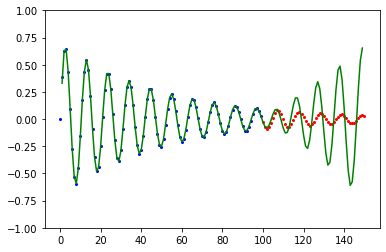

36300 3.3704499187282216e-05 0.0021497933707846444


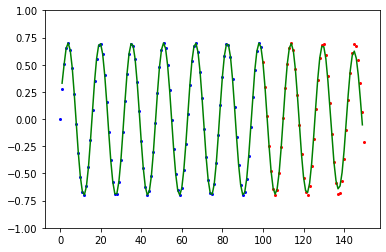

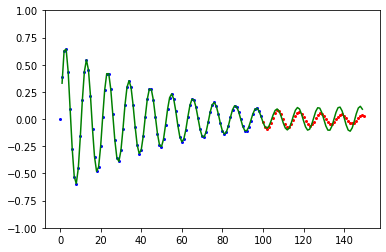

44400 3.6405246448023645e-05 0.002950811169273593


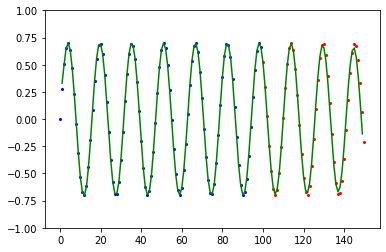

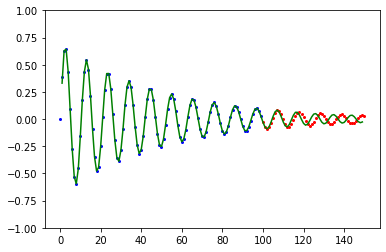

59400 3.359859098728133e-05 0.0005155489306806556


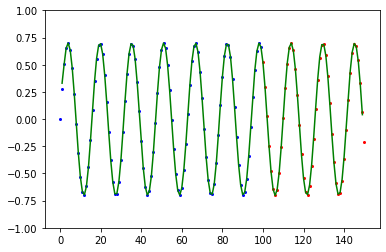

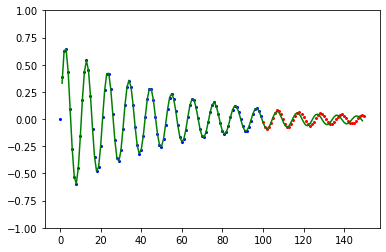

62100 3.3572022029229755e-05 0.00048411854998641927


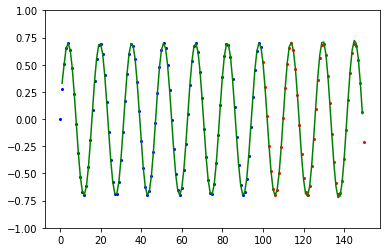

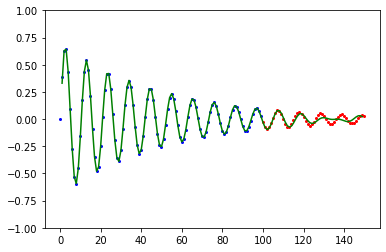

68100 3.3365087486725116e-05 0.026500680519578594


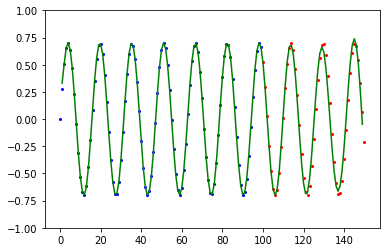

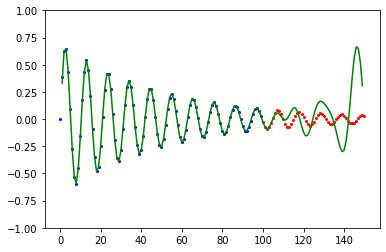

71200 3.4428062352140185e-05 0.3057199926373735


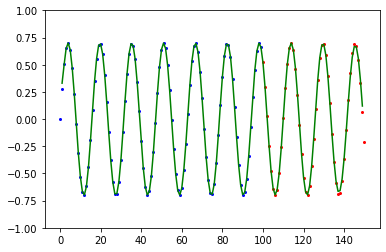

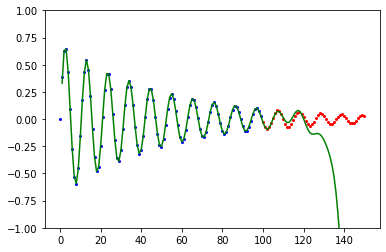

76600 3.31854505838765e-05 0.0004250706355091182


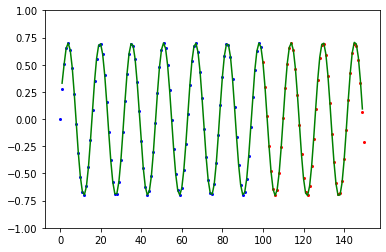

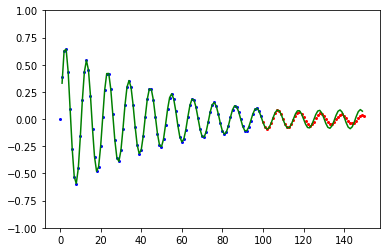

83100 3.360160479668304e-05 0.005362259808106015


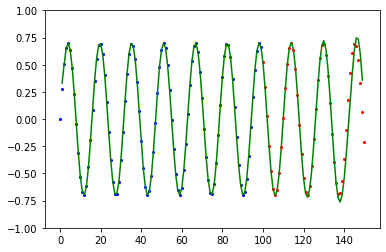

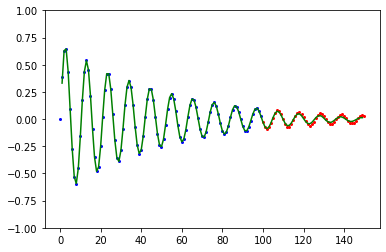

86900 3.451530167985513e-05 0.0013934932319351722


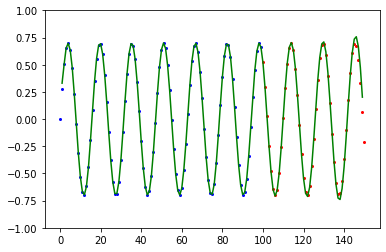

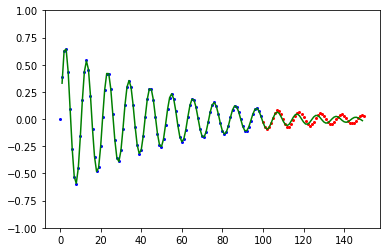

92800 3.308780430699414e-05 7.202378547557508e-05


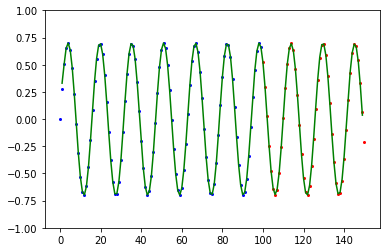

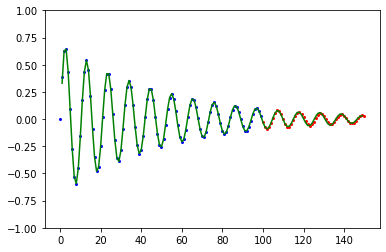

95700 0.015464014840962282 0.00013280890915592225


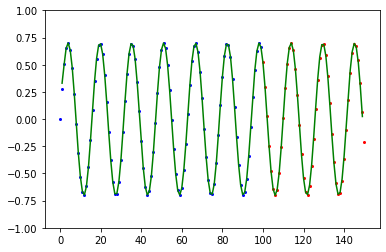

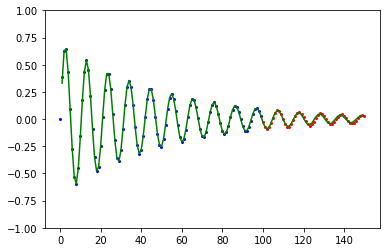

98600 3.358451275660686e-05 0.00011326856033624665


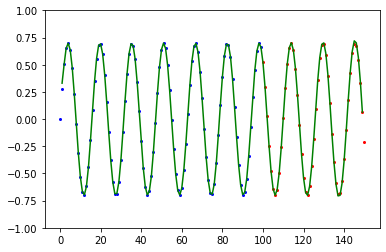

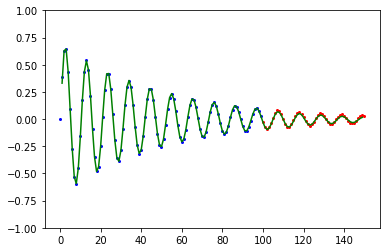

102500 3.477068044469304e-05 0.0018562180380383153


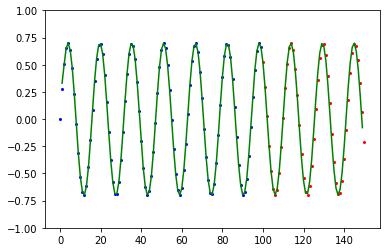

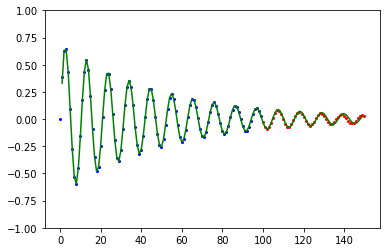

108800 3.378879193314123e-05 0.000244445715389617


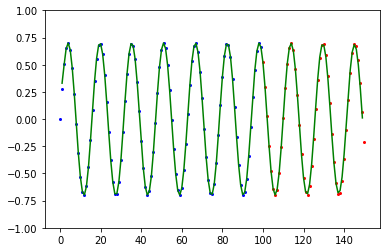

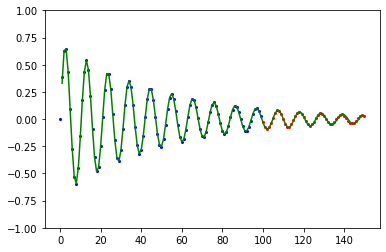

112700 3.383098236321548e-05 0.011795628580756166


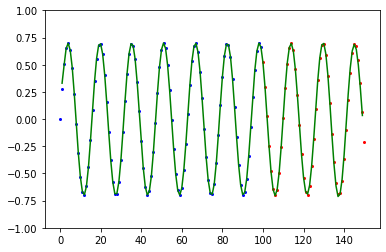

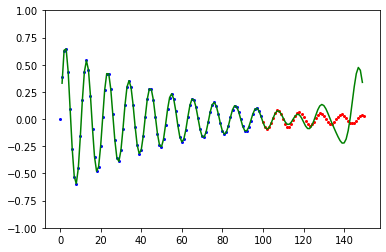

116000 3.346281522312592e-05 0.0020282500703752075


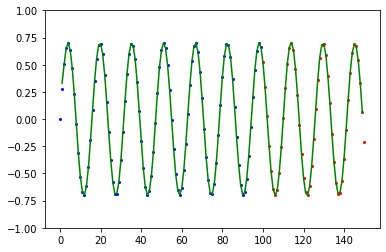

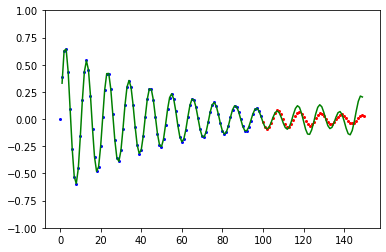

122300 3.3189949744262175e-05 0.0038374671850817405


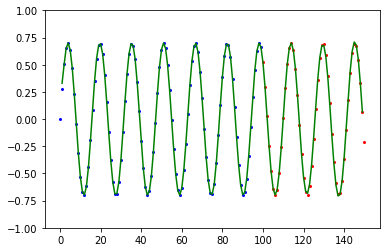

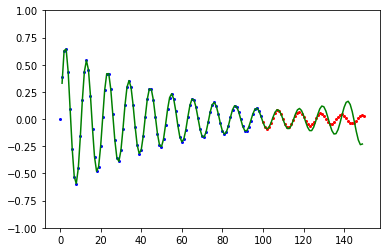

128300 3.3375963074849976e-05 0.0019371907008477727


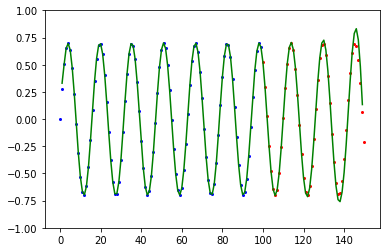

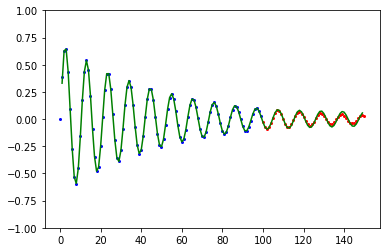

130800 3.343220719880083e-05 0.00048796373079540846


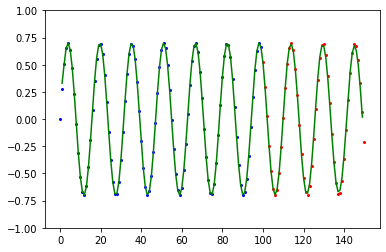

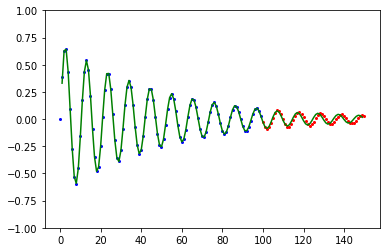

137500 3.3221143220711704e-05 6.154826978758275e-05


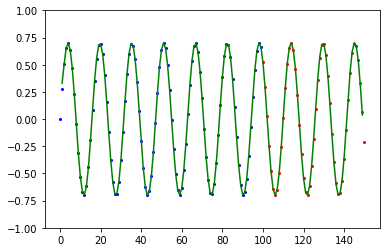

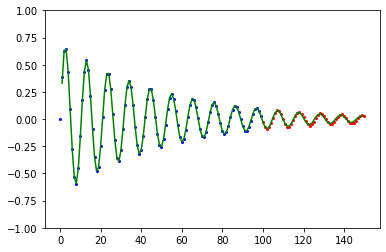

141800 3.552337203861115e-05 0.0006146266192819341


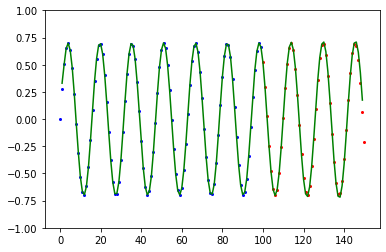

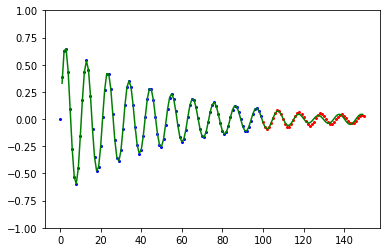

146300 3.375782107485488e-05 0.000566476835730665


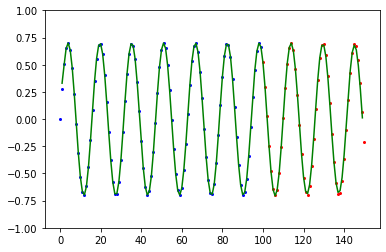

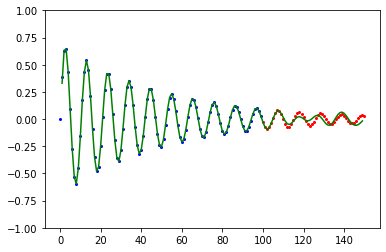

149700 3.4218892264845597e-05 0.062459800552369125


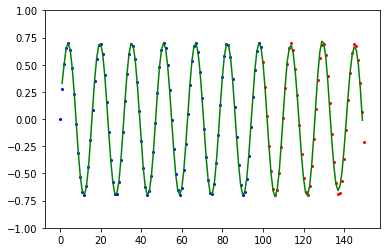

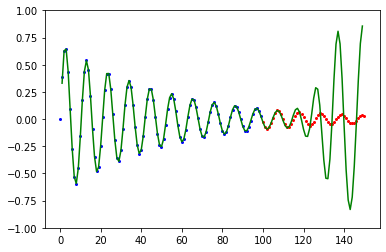

155900 3.3352078681947244e-05 0.2731923796486254


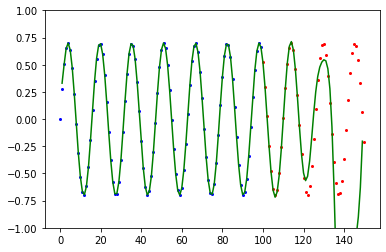

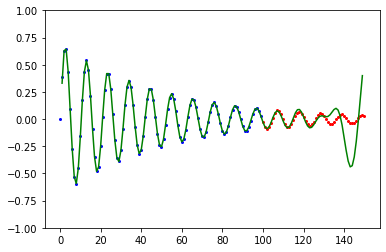

160100 3.337339622399071e-05 0.03138288860545395


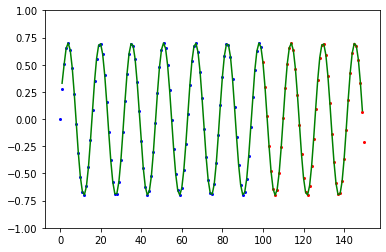

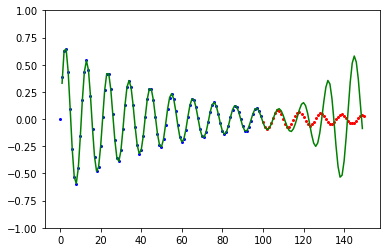

170600 3.4217944023361545e-05 2.572542043591553e-05


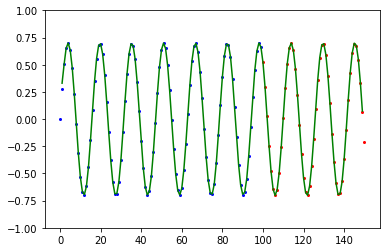

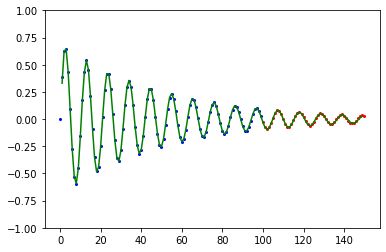

194400 3.314438754106573e-05 6.449022702667573e-05


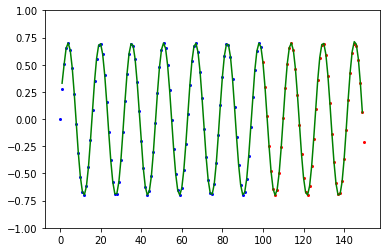

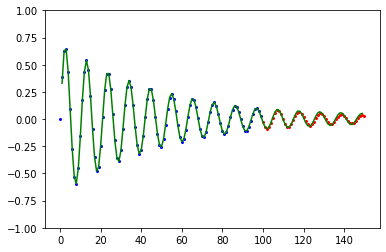

202800 3.406957465998434e-05 2.7075173265574795


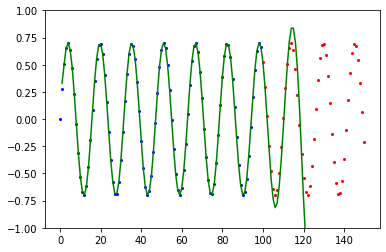

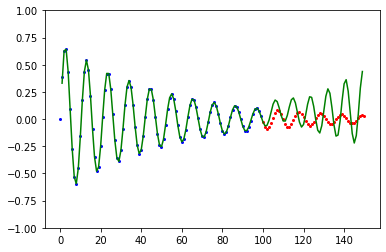

216000 3.368731083874205e-05 0.07184988767170715


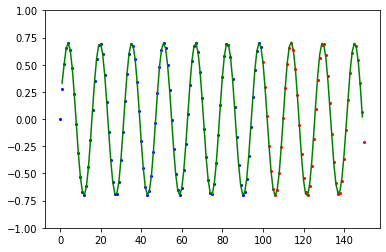

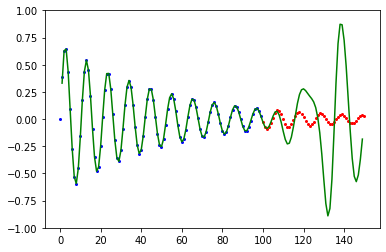

219500 3.3436686665642894e-05 0.0035192393915066313


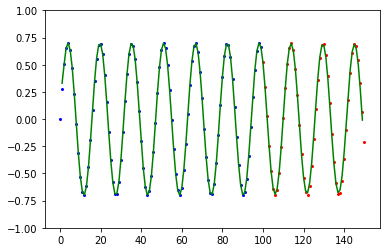

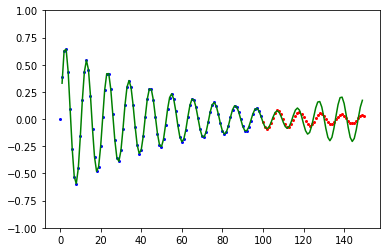

225000 3.479988252854757e-05 0.0003566239739906208


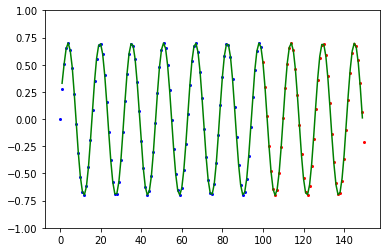

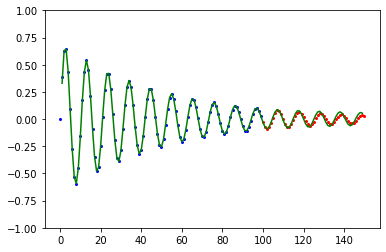

231300 3.4202972614768674e-05 0.00020529738602501624


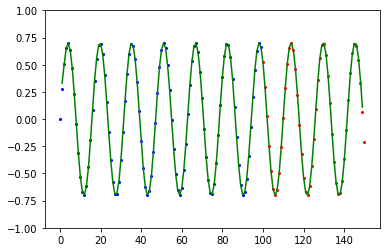

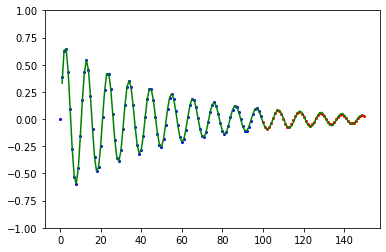

235400 3.3131144489950744e-05 1.0549797540724282e-05


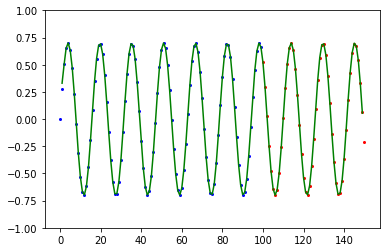

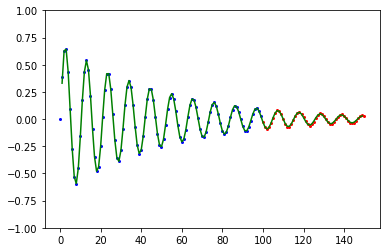

240900 3.3993341418881005e-05 0.0009013752050625032


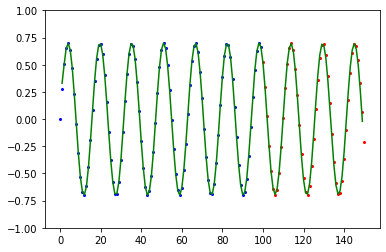

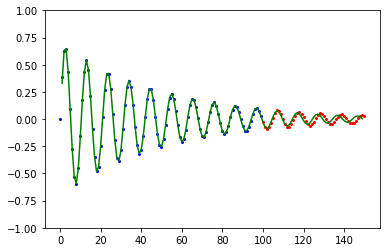

244200 3.3784511227690715e-05 0.0008370986965974214


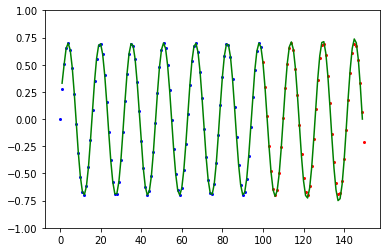

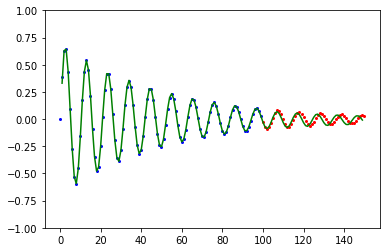

247600 3.345502702152309e-05 0.0004068094575578398


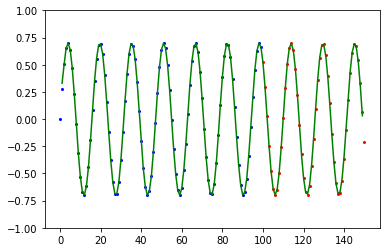

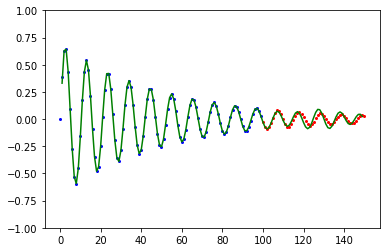

252400 3.3873574007320915e-05 0.0013217800488687479


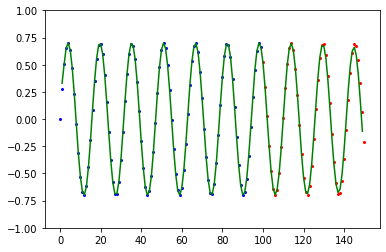

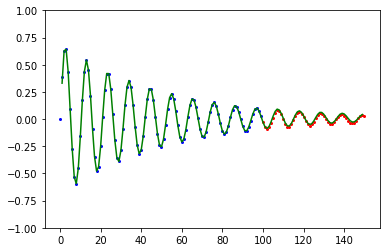

255400 3.317561966014239e-05 0.0008320787542958302


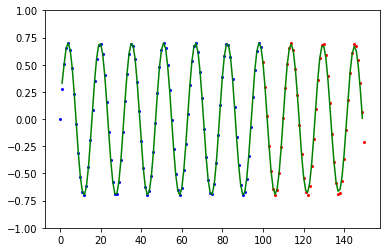

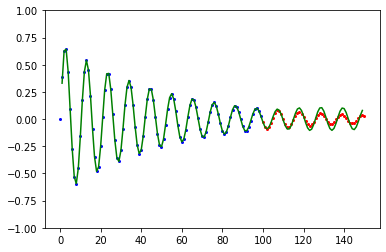

260900 3.372370969198476e-05 0.0006103190679984418


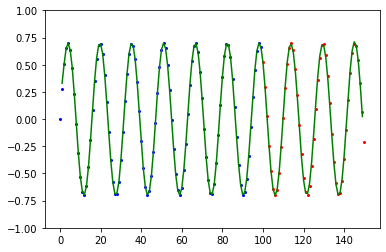

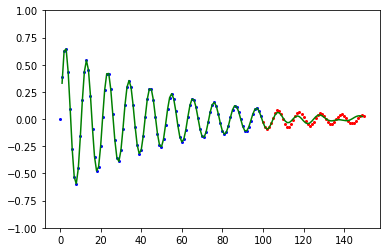

265000 3.377172455290489e-05 0.013981282814794209


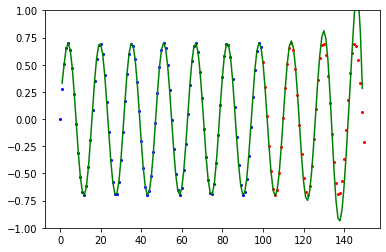

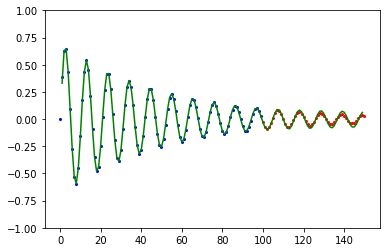

271000 3.393955322805407e-05 0.00030405876315569587


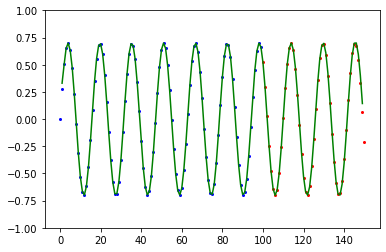

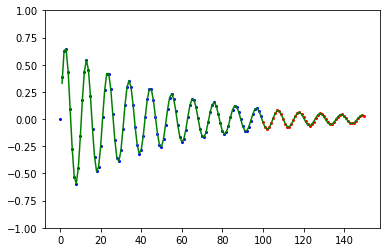

In [33]:
print('best:', test_result[min_idx][0:3])
for pak in test_result:
    i, i_loss, t_loss, _, ys = pak
    print(i, i_loss, t_loss)
    for idx in [0, 1]:
        plt.scatter(range(len(true1[idx])), true1[idx], c='b', s=4)
        plt.scatter(jnp.array(range(len(true2[idx])))+len(true1[idx]), true2[idx], c='r', s=4)
        plt.plot(jnp.array(range(len(ys[idx])))+1, ys[idx], c='g')
        plt.ylim(-1,1)
        plt.show()

In [34]:
sum([_[2] for _ in test_result])/len(test_result)

Array(0.07282886, dtype=float64)

In [35]:
len(test_result)

50